# Optimización de Hiperparámetros con Optuna
## LightGBM + feval `hotel_recall_minus_fpratio` — Fraude en Hospedaje (MCC 7011)

**Objetivo**: Encontrar la configuración de hiperparámetros de LightGBM que maximice la detección de fraude hotelero minimizando los falsos positivos, usando como función objetivo la métrica M2 definida en el notebook 04.

**Estrategia**:
1. Búsqueda bayesiana con Optuna (TPE Sampler) sobre el espacio de hiperparámetros de LightGBM
2. Early stopping en cada trial usando M2 como feval en validación (mes 5)
3. Reentreno del modelo final con los mejores parámetros sobre todo el train (meses 1–5)
4. Evaluación final en test junio con comparación vs baseline

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from pathlib import Path
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)
import warnings, json
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", None)

# ── Configuración global ──────────────────────────────────────────────────
RANDOM_STATE    = 42
N_TRIALS        = 60       # trials Optuna
EARLY_STOPPING  = 40       # rondas sin mejora para parar
NUM_BOOST_MAX   = 600      # máximo de árboles por trial
ALPHA_M2        = 0.5      # peso del FP ratio en M2
THRESHOLDS      = np.linspace(0.05, 0.65, 13)

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Optuna    : {optuna.__version__}")
print(f"LightGBM  : {lgb.__version__}")
print(f"Resultados: {RESULTS_DIR}")


Optuna    : 4.8.0
LightGBM  : 4.6.0
Resultados: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/results


## 2. Carga de datos y preparación de matrices

In [2]:
train_df = pd.read_csv(DATA_PROC / "train_features.csv")
test_df  = pd.read_csv(DATA_PROC / "test_features_june.csv")

for col in ["is_fraud","is_international","is_hotel","hotel_international","hotel_high_distance"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].astype(bool)

# Split interno: meses 1-4 → train_inner, mes 5 → val
train_inner = train_df[train_df["transaction_month"] < 5].copy()
val_df      = train_df[train_df["transaction_month"] == 5].copy()

TARGET = "is_fraud"
manual_drop = {
    TARGET,
    "transaction_id","pan_masked","pan_hash","DE2_PAN",
    "DE35_track2_data_masked","DE37_retrieval_reference_number",
    "DE38_authorization_code","DE41_terminal_id","DE42_card_acceptor_id",
    "DE43_card_acceptor_name_location","DE102_account_id_1","DE103_account_id_2",
    "client_home_city","bank_code","bank_name","bank_country","bank_tier",
    "approved","DE39_response_code","response_description",
    "DE44_additional_response_data","transaction_date","transaction_datetime",
}

def build_matrix(train_p, val_p, test_p):
    all_cols  = [c for c in train_p.columns if c not in manual_drop]
    cat_cols  = train_p[all_cols].select_dtypes(include=["object","category","string"]).columns.tolist()
    low_card  = [c for c in cat_cols if train_p[c].nunique() <= 50]
    high_card = [c for c in cat_cols if train_p[c].nunique() >  50]
    feat_cols = [c for c in all_cols if c not in high_card]

    X_tr = pd.get_dummies(train_p[feat_cols], columns=low_card, drop_first=True, dtype=float)
    X_va = pd.get_dummies(val_p[feat_cols],   columns=low_card, drop_first=True, dtype=float)
    X_te = pd.get_dummies(test_p[feat_cols],  columns=low_card, drop_first=True, dtype=float)
    X_va = X_va.reindex(columns=X_tr.columns, fill_value=0)
    X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    return (X_tr, train_p[TARGET].astype(int),
            X_va, val_p[TARGET].astype(int),
            X_te, test_p[TARGET].astype(int))

X_train, y_train, X_val, y_val, X_test, y_test = build_matrix(train_inner, val_df, test_df)

hotel_mask_val  = val_df["is_hotel"].values.astype(bool)
hotel_mask_test = test_df["is_hotel"].values.astype(bool)
y_val_np        = y_val.values
y_test_np       = y_test.values

# También build matrix para reentreno final (meses 1-5 completos)
X_train_full, y_train_full, _, _, _, _ = build_matrix(train_df, val_df, test_df)
hotel_mask_full_val = train_df["is_hotel"].values.astype(bool)  # no usada en reentreno

print(f"Train interno : {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Features      : {X_train.shape[1]}")
print(f"Hotel val     : {hotel_mask_val.sum()} txns  | fraudes: {y_val_np[hotel_mask_val].sum()}")
print(f"Hotel test    : {hotel_mask_test.sum()} txns  | fraudes: {y_test_np[hotel_mask_test].sum()}")


Train interno : 66,644 | Val: 17,173 | Test: 16,186
Features      : 108
Hotel val     : 1511 txns  | fraudes: 73
Hotel test    : 1457 txns  | fraudes: 73


## 3. feval M2 — `hotel_recall_minus_fpratio`

Métrica de optimización principal: `recall_hotel − α · FP_ratio_hotel`.  
Búsqueda dinámica de umbral en cada evaluación para evitar colapso con el desbalance de clases.

In [3]:
def _cm_hotel(y_h, p_h, t):
    y_pred = (p_h >= t).astype(int)
    tp = int(np.sum((y_h == 1) & (y_pred == 1)))
    fp = int(np.sum((y_h == 0) & (y_pred == 1)))
    fn = int(np.sum((y_h == 1) & (y_pred == 0)))
    return tp, fp, fn


def make_feval_m2(mask, y_true_full, alpha=ALPHA_M2):
    """Closure: feval hotel_recall_minus_fpratio para el set de validación."""
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p   = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
            s   = rec - alpha * fpr
            if s > best:
                best = s
        return "hotel_recall_minus_fpratio", best, True
    return feval


feval_m2_val = make_feval_m2(hotel_mask_val, y_val_np)

# Verificación rápida con predicciones aleatorias
_dummy = np.random.rand(len(y_val_np))
_name, _val, _higher = feval_m2_val(_dummy, None)
print(f"feval_m2_val (dummy): {_name} = {_val:.4f}  higher_better={_higher}")
print("✅ feval M2 lista.")


feval_m2_val (dummy): hotel_recall_minus_fpratio = 0.4972  higher_better=True
✅ feval M2 lista.


## 4. Función objetivo de Optuna

El espacio de búsqueda cubre los hiperparámetros de LightGBM con mayor impacto en detección de fraude desbalanceado. El resultado del trial es el mejor `hotel_recall_minus_fpratio` en validación (mes 5).

In [4]:
lgb_train_ds = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
lgb_val_ds   = lgb.Dataset(X_val,   label=y_val,   reference=lgb_train_ds, free_raw_data=False)


def objective(trial: optuna.Trial) -> float:
    params = {
        # arquitectura
        "num_leaves":        trial.suggest_int("num_leaves", 15, 200),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "max_bin":           trial.suggest_int("max_bin", 63, 255),
        # learning
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        # regularización
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 2.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 0.5),
        # desbalance
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 5.0, 30.0),
        # fijos
        "objective":    "binary",
        "force_col_wise": True,
        "verbose":       -1,
        "random_state":  RANDOM_STATE,
        "n_jobs":        4,
    }

    evals_result = {}
    booster = lgb.train(
        params,
        lgb_train_ds,
        num_boost_round = NUM_BOOST_MAX,
        valid_sets      = [lgb_val_ds],
        valid_names     = ["val"],
        feval           = feval_m2_val,
        callbacks       = [
            lgb.early_stopping(stopping_rounds=EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=0),
            lgb.record_evaluation(evals_result),
        ],
    )

    best_score = booster.best_score["val"].get("hotel_recall_minus_fpratio", -np.inf)
    # Guardar nro de árboles usados para el reentreno final
    trial.set_user_attr("best_iteration", booster.best_iteration)
    return best_score


print("Función objetivo definida.")
print(f"Espacio de búsqueda: 10 hiperparámetros  |  {N_TRIALS} trials planificados.")


Función objetivo definida.
Espacio de búsqueda: 10 hiperparámetros  |  60 trials planificados.


## 5. Búsqueda bayesiana con Optuna (TPE Sampler)

In [5]:
study = optuna.create_study(
    direction  = "maximize",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner     = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20),
    study_name = "lgb_hotel_fraud_m2",
)

print(f"Ejecutando {N_TRIALS} trials — esto puede tardar varios minutos...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best  = study.best_trial
print(f"\n{'='*55}")
print(f"Mejor trial   : #{best.number}")
print(f"Mejor score M2: {best.value:.4f}  (hotel_recall − 0.5·FP_ratio en val)")
print(f"Mejor iter    : {best.user_attrs.get('best_iteration', 'N/A')} árboles")
print(f"\nHiperparámetros óptimos:")
for k, v in best.params.items():
    print(f"  {k:<22}: {v}")


Ejecutando 60 trials — esto puede tardar varios minutos...


  0%|          | 0/60 [00:00<?, ?it/s]

[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


...

[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.


[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.
[LightGBM] [Fatal] Cannot change max_bin after constructed Dataset handle.



Mejor trial   : #21
Mejor score M2: 0.6046  (hotel_recall − 0.5·FP_ratio en val)
Mejor iter    : 86 árboles

Hiperparámetros óptimos:
  num_leaves            : 147
  max_depth             : 10
  min_child_samples     : 20
  max_bin               : 93
  learning_rate         : 0.1359953862282837
  subsample             : 0.9880791545970978
  colsample_bytree      : 0.6550604726961442
  reg_alpha             : 0.0024094496531941565
  reg_lambda            : 0.001167345258388437
  min_split_gain        : 0.2830490167548362
  scale_pos_weight      : 12.89161581930564


## 6. Análisis de la búsqueda

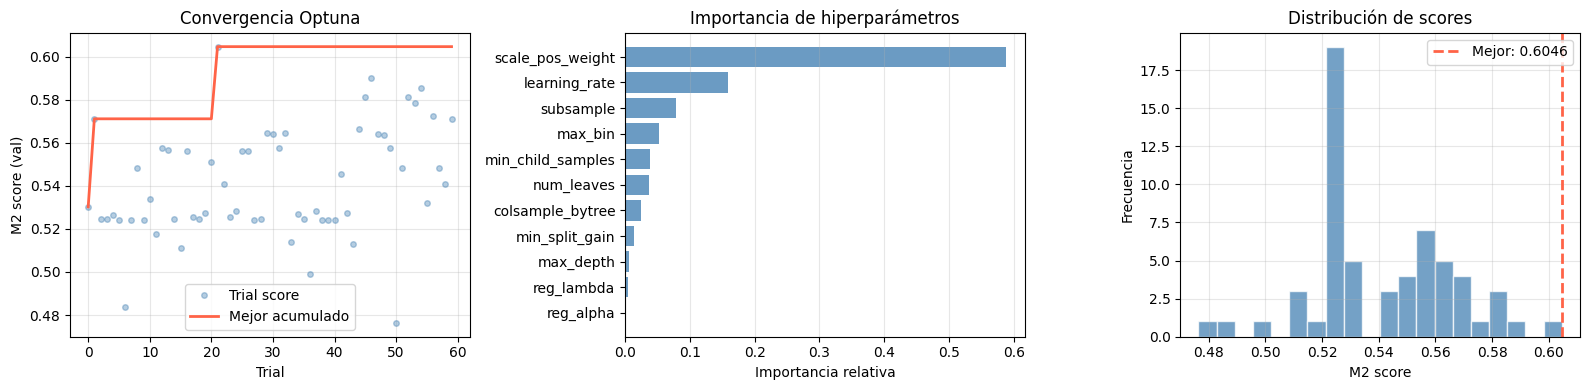

Trials guardados: results/optuna_trials.csv

Top 5 trials:
 number    value
     21 0.604620
     46 0.590137
     54 0.585188
     52 0.581117
     45 0.581117


In [6]:
trials_df = study.trials_dataframe(attrs=("number","value","params","user_attrs"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Convergencia ──
ax = axes[0]
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
ax.plot(vals, "o", alpha=0.4, markersize=4, color="steelblue", label="Trial score")
ax.plot(best_so_far, "-", color="tomato", linewidth=2, label="Mejor acumulado")
ax.set_xlabel("Trial"); ax.set_ylabel("M2 score (val)")
ax.set_title("Convergencia Optuna"); ax.legend(); ax.grid(alpha=0.3)

# ── Importancia de hiperparámetros ──
ax2 = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    keys   = list(importance.keys())
    values = list(importance.values())
    ax2.barh(keys[::-1], values[::-1], color="steelblue", alpha=0.8)
    ax2.set_xlabel("Importancia relativa"); ax2.set_title("Importancia de hiperparámetros")
    ax2.grid(alpha=0.3, axis="x")
except Exception as e:
    ax2.text(0.5, 0.5, str(e), ha="center", va="center", transform=ax2.transAxes)

# ── Distribución de scores ──
ax3 = axes[2]
ax3.hist(vals, bins=20, color="steelblue", alpha=0.75, edgecolor="white")
ax3.axvline(best.value, color="tomato", linewidth=2, linestyle="--",
            label=f"Mejor: {best.value:.4f}")
ax3.set_xlabel("M2 score"); ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de scores"); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optuna_study_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# Guardar resultados del estudio
trials_df.to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)
print(f"Trials guardados: results/optuna_trials.csv")
print(f"\nTop 5 trials:")
print(trials_df.sort_values("value", ascending=False).head(5)[
    ["number", "value"]
].to_string(index=False))


## 7. Modelo final — reentreno con mejores hiperparámetros (meses 1–5)

In [7]:
best_params = {**best.params,
               "objective": "binary", "force_col_wise": True,
               "verbose": -1, "random_state": RANDOM_STATE, "n_jobs": 4}
best_n_iter = best.user_attrs.get("best_iteration", 200)

# Reentreno sobre meses 1-5 completos (train_full) con num_boost_round fijo
lgb_full_ds = lgb.Dataset(X_train_full, label=y_train_full, free_raw_data=False)

final_model = lgb.train(
    best_params,
    lgb_full_ds,
    num_boost_round = best_n_iter,
    callbacks       = [lgb.log_evaluation(period=0)],
)

print(f"Modelo final entrenado con {best_n_iter} árboles sobre {len(y_train_full):,} filas (meses 1-5).")
print(f"Parámetros usados:")
for k, v in best_params.items():
    if k not in {"objective","force_col_wise","verbose","random_state","n_jobs"}:
        print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")


Modelo final entrenado con 86 árboles sobre 83,817 filas (meses 1-5).
Parámetros usados:
  num_leaves            : 147
  max_depth             : 10
  min_child_samples     : 20
  max_bin               : 93
  learning_rate         : 0.1360
  subsample             : 0.9881
  colsample_bytree      : 0.6551
  reg_alpha             : 0.0024
  reg_lambda            : 0.0012
  min_split_gain        : 0.2830
  scale_pos_weight      : 12.8916


## 8. Evaluación en Test Junio

In [8]:
proba_test  = np.clip(final_model.predict(X_test), 0, 1)
proba_hotel = proba_test[hotel_mask_test]
y_hotel     = y_test_np[hotel_mask_test]

# ── Búsqueda del umbral óptimo (minimiza FP ratio con recall_hotel >= 0.65) ──
threshold_rows = []
for t in THRESHOLDS:
    tp, fp, fn = _cm_hotel(y_hotel, proba_hotel, t)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fpr  = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    threshold_rows.append({"t": round(t,2), "tp": tp, "fp": fp, "fn": fn,
                            "recall": rec, "precision": prec, "fp_ratio": fpr})

thr_df = pd.DataFrame(threshold_rows)
valid  = thr_df[thr_df["recall"] >= 0.65]
best_t = valid.loc[valid["fp_ratio"].idxmin()] if not valid.empty \
         else thr_df.loc[thr_df["fp_ratio"].idxmin()]

# ── Métricas globales ──
auc_roc = roc_auc_score(y_test_np, proba_test)
pr_auc  = average_precision_score(y_test_np, proba_test)

print("=" * 60)
print("EVALUACIÓN MODELO OPTIMIZADO — Test Junio (hotel MCC 7011)")
print("=" * 60)
print(f"\n  Umbral seleccionado : {best_t['t']}")
print(f"  TP hotel            : {int(best_t['tp'])}")
print(f"  FP hotel            : {int(best_t['fp'])}")
print(f"  FN hotel            : {int(best_t['fn'])}")
print(f"  Recall hotel        : {best_t['recall']*100:.1f}%")
print(f"  Precisión hotel     : {best_t['precision']*100:.1f}%")
print(f"  FP ratio hotel      : {best_t['fp_ratio']*100:.1f}%  ← métrica objetivo")
print(f"  AUC-ROC global      : {auc_roc:.4f}")
print(f"  PR-AUC global       : {pr_auc:.4f}")

print(f"\n  Threshold sweep (hotel):")
print(thr_df[["t","tp","fp","fn","recall","precision","fp_ratio"]].to_string(index=False))


EVALUACIÓN MODELO OPTIMIZADO — Test Junio (hotel MCC 7011)

  Umbral seleccionado : 0.25
  TP hotel            : 49
  FP hotel            : 23
  FN hotel            : 24
  Recall hotel        : 67.1%
  Precisión hotel     : 68.1%
  FP ratio hotel      : 31.9%  ← métrica objetivo
  AUC-ROC global      : 0.9025
  PR-AUC global       : 0.8049

  Threshold sweep (hotel):
   t  tp  fp  fn   recall  precision  fp_ratio
0.05  52 152  21 0.712329   0.254902  0.745098
0.10  51  71  22 0.698630   0.418033  0.581967
0.15  49  45  24 0.671233   0.521277  0.478723
0.20  49  30  24 0.671233   0.620253  0.379747
0.25  49  23  24 0.671233   0.680556  0.319444
0.30  47  19  26 0.643836   0.712121  0.287879
0.35  47  16  26 0.643836   0.746032  0.253968
0.40  45  12  28 0.616438   0.789474  0.210526
0.45  44  12  29 0.602740   0.785714  0.214286
0.50  43  11  30 0.589041   0.796296  0.203704
0.55  43   9  30 0.589041   0.826923  0.173077
0.60  43   9  30 0.589041   0.826923  0.173077
0.65  41   9  32 0.

## 9. Comparación vs Baseline

In [9]:
import pandas as _pd

# ── Baseline real desde predicciones guardadas ─────────────────────────────
_preds  = _pd.read_csv(RESULTS_DIR / "baseline_predictions_june.csv")
_test_h = test_df[["transaction_id","is_hotel"]].copy()
_test_h["is_hotel"] = _test_h["is_hotel"].astype(bool)
_merged = _preds.merge(_test_h, on="transaction_id", how="left")
_hotel  = _merged[_merged["is_hotel"]].copy()

_y_h = _hotel["is_fraud_real"].astype(int).values
_p_h = _hotel["fraud_probability_baseline"].values

# Seleccionar umbral óptimo del baseline: minimiza FP ratio con recall >= 0.65
_base_rows = []
for _t in THRESHOLDS:
    _tp, _fp, _fn = _cm_hotel(_y_h, _p_h, _t)
    _rec = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
    _fpr = _fp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
    _base_rows.append({"t": _t, "tp": _tp, "fp": _fp, "fn": _fn,
                        "recall": _rec, "fp_ratio": _fpr})
_base_df    = _pd.DataFrame(_base_rows)
_base_valid = _base_df[_base_df["recall"] >= 0.65]
_base_best  = _base_valid.loc[_base_valid["fp_ratio"].idxmin()] if not _base_valid.empty \
              else _base_df.loc[_base_df["fp_ratio"].idxmin()]

BASELINE_HOTEL = {
    "model":         "Baseline (umbral óptimo hotel)",
    "tp_hotel":      int(_base_best["tp"]),
    "fp_hotel":      int(_base_best["fp"]),
    "fn_hotel":      int(_base_best["fn"]),
    "recall_hotel":  _base_best["recall"],
    "fp_ratio_hotel":_base_best["fp_ratio"],
    "auc_roc":       0.8995,
    "threshold":     _base_best["t"],
}

OPT_HOTEL = {
    "model":         "Optimizado (Optuna + M2)",
    "tp_hotel":      int(best_t["tp"]),
    "fp_hotel":      int(best_t["fp"]),
    "fn_hotel":      int(best_t["fn"]),
    "recall_hotel":  best_t["recall"],
    "fp_ratio_hotel":best_t["fp_ratio"],
    "auc_roc":       auc_roc,
    "threshold":     best_t["t"],
}

comparison = pd.DataFrame([BASELINE_HOTEL, OPT_HOTEL])
comparison["recall_pct"]   = (comparison["recall_hotel"]   * 100).round(1)
comparison["fp_ratio_pct"] = (comparison["fp_ratio_hotel"] * 100).round(1)

cols = ["model","threshold","tp_hotel","fp_hotel","fn_hotel",
        "recall_pct","fp_ratio_pct","auc_roc"]

print("\n" + "=" * 65)
print("COMPARACIÓN: Baseline vs Modelo Optimizado — Hotel MCC 7011")
print("=" * 65)
print(comparison[cols].to_string(index=False))

delta_fp  = BASELINE_HOTEL["fp_ratio_hotel"] - OPT_HOTEL["fp_ratio_hotel"]
delta_rec = OPT_HOTEL["recall_hotel"]        - BASELINE_HOTEL["recall_hotel"]
print(f"\n  Δ FP ratio : {delta_fp*100:+.1f}pp  (positivo = mejora en optimizado)")
print(f"  Δ Recall   : {delta_rec*100:+.1f}pp")
print(f"\n  Nota: Ambos umbrales seleccionados post-hoc minimizando FP ratio")
print(f"  con restricción recall_hotel ≥ 65%.")



COMPARACIÓN: Baseline vs Modelo Optimizado — Hotel MCC 7011
                         model  threshold  tp_hotel  fp_hotel  fn_hotel  recall_pct  fp_ratio_pct  auc_roc
Baseline (umbral óptimo hotel)       0.60        51        56        22        69.9          52.3  0.89950
      Optimizado (Optuna + M2)       0.25        49        23        24        67.1          31.9  0.90248

  Δ FP ratio : +20.4pp  (positivo = mejora en optimizado)
  Δ Recall   : -2.7pp

  Nota: Ambos umbrales seleccionados post-hoc minimizando FP ratio
  con restricción recall_hotel ≥ 65%.


## 10. Visualizaciones finales

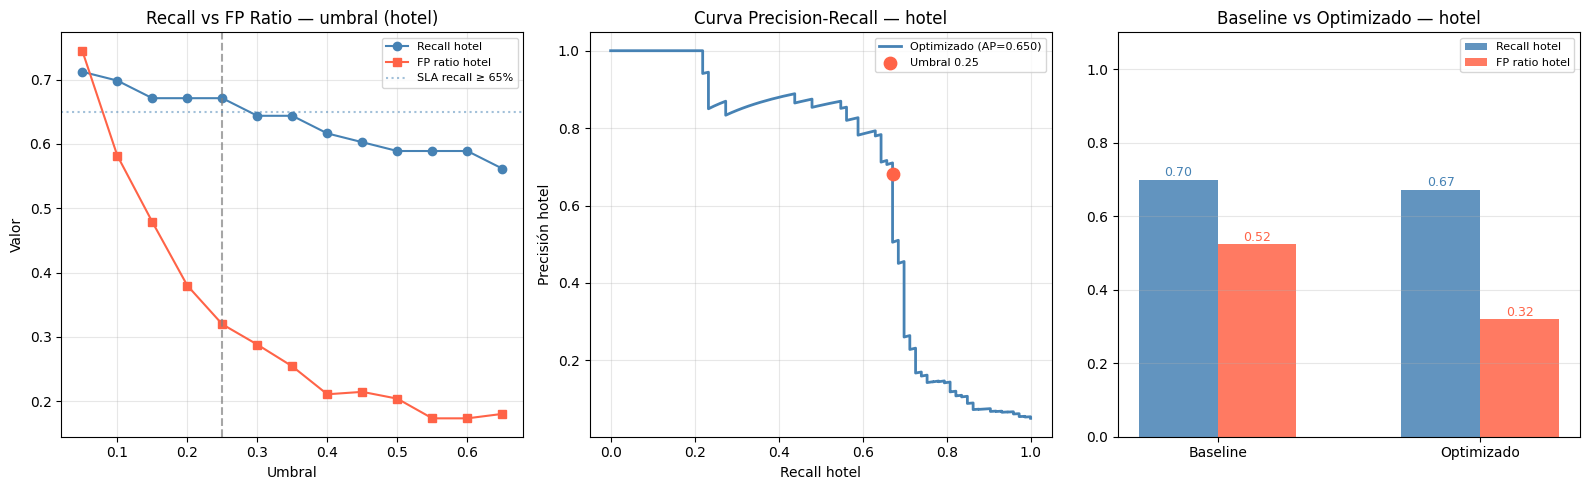

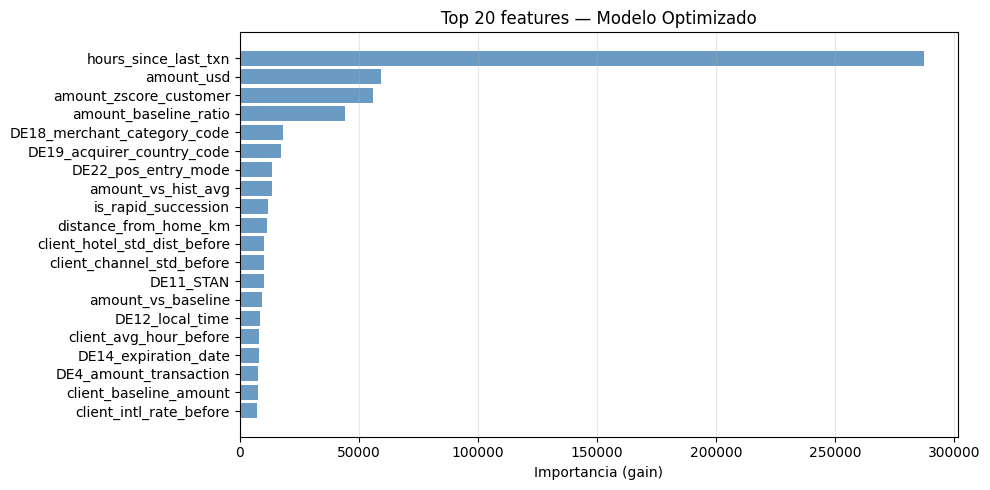

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Threshold sweep: Recall y FP ratio vs umbral ──
ax = axes[0]
ax.plot(thr_df["t"], thr_df["recall"],   "o-", color="steelblue", label="Recall hotel")
ax.plot(thr_df["t"], thr_df["fp_ratio"], "s-", color="tomato",    label="FP ratio hotel")
ax.axvline(best_t["t"], color="gray", linestyle="--", alpha=0.7)
ax.axhline(0.65, color="steelblue", linestyle=":", alpha=0.5, label="SLA recall ≥ 65%")
ax.set_xlabel("Umbral"); ax.set_ylabel("Valor")
ax.set_title("Recall vs FP Ratio — umbral (hotel)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Curva Precision-Recall (hotel) ──
ax2 = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_hotel, proba_hotel)
ap_hotel = average_precision_score(y_hotel, proba_hotel)
ax2.plot(rec_c, prec_c, color="steelblue", linewidth=2,
         label=f"Optimizado (AP={ap_hotel:.3f})")
ax2.scatter([best_t["recall"]], [best_t["precision"]],
            color="tomato", zorder=5, s=80, label=f"Umbral {best_t['t']:.2f}")
ax2.set_xlabel("Recall hotel"); ax2.set_ylabel("Precisión hotel")
ax2.set_title("Curva Precision-Recall — hotel"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Comparación baseline vs optimizado (barras) ──
ax3 = axes[2]
models   = ["Baseline", "Optimizado"]
recalls  = [BASELINE_HOTEL["recall_hotel"],   OPT_HOTEL["recall_hotel"]]
fp_ratios= [BASELINE_HOTEL["fp_ratio_hotel"], OPT_HOTEL["fp_ratio_hotel"]]
x        = np.arange(2); w = 0.3
ax3.bar(x - w/2, recalls,   w, label="Recall hotel",   color="steelblue", alpha=0.85)
ax3.bar(x + w/2, fp_ratios, w, label="FP ratio hotel", color="tomato",    alpha=0.85)
for i, (r, f) in enumerate(zip(recalls, fp_ratios)):
    ax3.text(i-w/2, r+0.01, f"{r:.2f}", ha="center", fontsize=9, color="steelblue")
    ax3.text(i+w/2, f+0.01, f"{f:.2f}", ha="center", fontsize=9, color="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(models)
ax3.set_ylim(0, 1.1); ax3.set_title("Baseline vs Optimizado — hotel")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Feature importance del modelo final ──
fi = pd.DataFrame({
    "feature":    final_model.feature_name(),
    "importance": final_model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue", alpha=0.8)
plt.xlabel("Importancia (gain)"); plt.title("Top 20 features — Modelo Optimizado")
plt.grid(alpha=0.3, axis="x"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Guardar resultados

In [11]:
with open(RESULTS_DIR / "best_params_optuna.json", "w") as f:
    json.dump({**best_params, "best_iteration": best_n_iter,
               "best_val_score_m2": best.value}, f, indent=2)

preds_out = pd.DataFrame({
    "transaction_id":       test_df["transaction_id"].values
                            if "transaction_id" in test_df.columns
                            else np.arange(len(test_df)),
    "is_hotel":             hotel_mask_test,
    "is_fraud_real":        y_test_np.astype(bool),
    "fraud_prob_optimized": proba_test.round(6),
    "pred_optimized":       (proba_test >= best_t["t"]).astype(bool),
    "threshold_used":       best_t["t"],
})
preds_out.to_csv(RESULTS_DIR / "optimized_predictions_june.csv", index=False)
comparison.to_csv(RESULTS_DIR / "comparison_baseline_vs_optimized.csv", index=False)

print("Archivos guardados en results/")
print()
print(comparison[["model","threshold","tp_hotel","fp_hotel",
                   "recall_pct","fp_ratio_pct","auc_roc"]].to_string(index=False))


Archivos guardados en results/

                         model  threshold  tp_hotel  fp_hotel  recall_pct  fp_ratio_pct  auc_roc
Baseline (umbral óptimo hotel)       0.60        51        56        69.9          52.3  0.89950
      Optimizado (Optuna + M2)       0.25        49        23        67.1          31.9  0.90248
